# Phase 2 — Stage 5: LSTM Autoencoder Training, Evaluation & Analysis

**Model B** — Deep Learning anomaly detector (sequence-based)  
**Baseline (Phase 1 Model A):** GMM K=12, F1=90.97%, AUC=95.76%  
**Goal:** Demonstrate that temporal sequence modeling improves detection over the IID GMM.

### Evaluation Strategy — Critical Note

Phase 1 used `train_test_split(shuffle=True)` (sklearn default), so `X_test` flows are in **random order**, not temporal order. With ~47% attack prevalence, virtually every 50-flow sliding window contains ≥1 attack flow — P(all benign in window) ≈ 0.53⁵⁰ ≈ 10⁻¹⁴. As a result `y_test_seq` is all-1, making window-level binary classification meaningless.

**Primary metric: per-flow AUC-ROC.**  
For each flow *i* we aggregate the reconstruction errors of all windows that contain flow *i*, then compute AUC against the original flow-level labels `y_test` (716K flows, 0=benign / 1=attack). This is the correct, principled evaluation for this dataset.

---
## Section 0: Imports & Configuration

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.initializers import GlorotUniform

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# ── Hyperparameters ──────────────────────────────────────────────────────────
WINDOW_SIZE = 50
FEATURES    = 34
LATENT_DIM  = 32
BATCH_SIZE  = 256
EPOCHS      = 100   # EarlyStopping will terminate well before this
PATIENCE    = 10    # Epochs to wait for val_loss improvement before stopping

PROJECT_ROOT = Path.cwd().parent

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"GPUs visible: {tf.config.list_physical_devices('GPU')}")
print(f"Project root: {PROJECT_ROOT}")

TensorFlow  : 2.21.0
NumPy       : 1.26.4
GPUs visible: []
Project root: /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project


---
## Section 1: Load Data

In [2]:
SEQ_DIR    = PROJECT_ROOT / 'outputs' / 'sequences'
PREPROC_DIR = PROJECT_ROOT / 'outputs' / 'preprocessing'

# Sequence data built in Stage 4
X_tr   = np.load(SEQ_DIR / 'X_train_seq.npy')      # (91098, 50, 34) benign-only
X_val  = np.load(SEQ_DIR / 'X_val_seq.npy')         # (30366, 50, 34) benign-only
X_test_seq       = np.load(SEQ_DIR / 'X_test_seq.npy')      # (716043, 50, 34)
y_test_seq_frac  = np.load(SEQ_DIR / 'y_test_seq_frac.npy') # attack fraction per window

# Original flow-level labels for per-flow AUC evaluation
y_test     = np.load(PREPROC_DIR / 'y_test.npy')             # (716092,) binary
y_test_mc  = np.load(PREPROC_DIR / 'y_test_multiclass.npy',
                     allow_pickle=True)                       # (716092,) string

print(f"X_tr           : {X_tr.shape}   — all benign (train)")
print(f"X_val          : {X_val.shape}  — all benign (val)")
print(f"X_test_seq     : {X_test_seq.shape}")
print(f"y_test_seq_frac: {y_test_seq_frac.shape}  min={y_test_seq_frac.min():.2f} max={y_test_seq_frac.max():.2f}")
print(f"y_test (flows) : {y_test.shape}  benign={( y_test==0).sum():,}  attack={(y_test==1).sum():,}")
print(f"\nNote: y_test_seq is all-1 because test flows were shuffled in Phase 1.")
print(f"Evaluation uses per-flow AUC (see notebook header for rationale).")

X_tr           : (121464, 50, 34)   — all benign (train)
X_val          : (30366, 50, 34)  — all benign (val)
X_test_seq     : (716043, 50, 34)
y_test_seq_frac: (716043,)  min=0.18 max=0.80
y_test (flows) : (716092,)  benign=379,587  attack=336,505

Note: y_test_seq is all-1 because test flows were shuffled in Phase 1.
Evaluation uses per-flow AUC (see notebook header for rationale).


---
## Section 2: LSTM Autoencoder Architecture

### Design Decisions

**1. Two LSTM layers in the encoder (128 → 64 units)**  
A single LSTM layer captures one temporal scale. The first layer (128 units, `return_sequences=True`) scans each timestep and builds local pattern representations — e.g., detecting a burst of identical destination ports (port scan) within 3–5 consecutive flows. The second layer (64 units, `return_sequences=False`) reads the *full sequence* output of the first layer and captures longer-range dependencies across the entire 50-flow window — e.g., a SYN→response→SYN→response beaconing rhythm spanning 20+ flows. The 128→64→32 funnel forces the network to distil increasingly abstract, compressed representations.

**2. `return_sequences=True` on Encoder LSTM 1 / `False` on Encoder LSTM 2**  
`return_sequences=True` outputs a hidden state vector at *every* timestep: shape `(batch, 50, 128)`. This preserves the full temporal trace for the next LSTM layer. `return_sequences=False` on the second encoder LSTM outputs only the **final** hidden state: shape `(batch, 64)`. This is the bottleneck — the entire 50-flow window compressed into 64 numbers. Without this compression, the decoder would have per-timestep guidance and could reconstruct without learning anything useful.

**3. `RepeatVector(50)` — broadcasting the latent vector**  
The bottleneck is a single 32-dimensional vector. The decoder LSTM needs a 3D input `(batch, 50, 32)`. `RepeatVector` broadcasts the latent `z` to all 50 timestep positions. The decoder must then *unroll* the compressed representation back into a 50-step sequence — this is exactly what forces the encoder to capture temporal structure: if it doesn't, the decoder cannot reconstruct.

**4. Xavier (Glorot Uniform) initialisation**  
Glorot uniform draws weights from Uniform(−√(6/(fan_in+fan_out)), +√(6/(fan_in+fan_out))). For tanh-activated LSTMs, this keeps the initial gate activations in the near-linear regime (|tanh(x)| ≈ |x| for small x), so gradients neither explode nor vanish in the first few epochs. Random normal initialisation risks saturating the forget gate, causing the model to forget all context immediately and preventing early learning.

**5. Forget gate bias initialised to 1.0**  
The forget gate equation is f_t = σ(W_f[h_{t−1}, x_t] + b_f). With b_f=0 (the default), the forget gate activates at σ(0)=0.5 — it throws away half the cell state before seeing any data. Setting b_f=1 starts the forget gate at σ(1)≈0.73, meaning the LSTM *remembers by default* and only forgets when it sees strong evidence. This is critical for a window of 50 flows: the LSTM must retain context from flow 1 when processing flow 49. Jozefowicz et al. (2015) showed empirically that b_f=1 consistently improves performance on long-sequence tasks.

**6. Gradient clipping (`clipnorm=1.0`)**  
LSTMs on long sequences can produce large gradients when a single flow strongly deviates from the learned pattern. Without clipping, one anomalous batch can cause a catastrophic weight update that destroys learned representations. `clipnorm=1.0` rescales the entire gradient vector to unit norm if its L2 norm exceeds 1 — preserving the gradient *direction* while bounding the step size. This is preferable to `clipvalue` which independently clips each dimension and can distort the direction.

**7. `TimeDistributed(Dense(34))`**  
Applies the same 34-unit dense layer independently to each of the 50 decoder output timesteps: `(batch, 50, 128) → (batch, 50, 34)`. The alternative of a single Dense on a flattened vector `(batch, 50*128)` would have 50× more parameters (a huge, over-parameterised output head) and would allow cross-timestep mixing in the output layer — destroying the per-timestep reconstruction loss we need.

**8. Linear output activation**  
After RobustScaler preprocessing, features are centred and scaled but *not* bounded. Some scaled features take negative values. A sigmoid or tanh output activation would clip reconstructions to [0,1] or [-1,1], introducing systematic output bias. Linear activation lets the decoder output arbitrary real values matching the input range.

In [3]:
def build_lstm_ae(window_size: int, n_features: int, latent_dim: int,
                  dropout_rate: float = 0.2) -> Model:
    """
    LSTM Autoencoder for sequence-level anomaly detection.

    Architecture
    ------------
    Input (50, 34)
      └── Encoder LSTM1 (128, return_sequences=True)
            └── Dropout(0.2)
              └── Encoder LSTM2 (64, return_sequences=False)  ← bottleneck
                    └── Dropout(0.2)
                      └── Dense(32, relu)  ← latent z
                            └── RepeatVector(50)
                              └── Decoder LSTM1 (64, return_sequences=True)
                                    └── Dropout(0.2)
                                      └── Decoder LSTM2 (128, return_sequences=True)
                                            └── Dropout(0.2)
                                              └── TimeDistributed(Dense(34, linear))
    Output (50, 34)
    """
    inputs = Input(shape=(window_size, n_features), name='input')

    # ── ENCODER ──────────────────────────────────────────────────────────────
    enc1 = LSTM(
        128, return_sequences=True,
        kernel_initializer=GlorotUniform(seed=SEED),
        recurrent_initializer=GlorotUniform(seed=SEED),
        bias_initializer='ones',   # forget gate bias=1: remember by default
        name='encoder_lstm1'
    )(inputs)
    enc1 = Dropout(dropout_rate, name='encoder_drop1')(enc1)

    enc2 = LSTM(
        64, return_sequences=False,   # bottleneck: compress to single vector
        kernel_initializer=GlorotUniform(seed=SEED),
        recurrent_initializer=GlorotUniform(seed=SEED),
        bias_initializer='ones',
        name='encoder_lstm2'
    )(enc1)
    enc2 = Dropout(dropout_rate, name='encoder_drop2')(enc2)

    # ── LATENT REPRESENTATION ─────────────────────────────────────────────────
    # Dense bottleneck — maximum compression before decoding
    latent = Dense(
        latent_dim, activation='relu',
        kernel_initializer=GlorotUniform(seed=SEED),
        name='latent'
    )(enc2)

    # ── DECODER ──────────────────────────────────────────────────────────────
    # Broadcast latent z to all 50 timesteps
    repeated = RepeatVector(window_size, name='repeat_vector')(latent)

    dec1 = LSTM(
        64, return_sequences=True,
        kernel_initializer=GlorotUniform(seed=SEED),
        recurrent_initializer=GlorotUniform(seed=SEED),
        bias_initializer='ones',
        name='decoder_lstm1'
    )(repeated)
    dec1 = Dropout(dropout_rate, name='decoder_drop1')(dec1)

    dec2 = LSTM(
        128, return_sequences=True,
        kernel_initializer=GlorotUniform(seed=SEED),
        recurrent_initializer=GlorotUniform(seed=SEED),
        bias_initializer='ones',
        name='decoder_lstm2'
    )(dec1)
    dec2 = Dropout(dropout_rate, name='decoder_drop2')(dec2)

    # Reconstruct all 50 timesteps independently
    outputs = TimeDistributed(
        Dense(n_features, activation='linear'),
        name='output'
    )(dec2)

    return Model(inputs=inputs, outputs=outputs, name='lstm_autoencoder')


lstm_ae = build_lstm_ae(WINDOW_SIZE, FEATURES, LATENT_DIM)
lstm_ae.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 50, 34)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm1 (LSTM)            │ (None, 50, 128)        │        83,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_drop1 (Dropout)         │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm2 (LSTM)            │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_drop2 (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm1 (LSTM)            │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_drop1 (Dropout)         │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm2 (LSTM)            │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_drop2 (Dropout)         │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 50, 34)         │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,978 (1.00 MB)

 Trainable params: 262,978 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
total_params = lstm_ae.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"  Encoder (LSTM1 + LSTM2 + Latent Dense): captures the normal traffic manifold")
print(f"  Decoder (LSTM1 + LSTM2 + Output):       reconstructs from compressed representation")
print(f"\nBottleneck compression ratio: {WINDOW_SIZE * FEATURES} input dims → {LATENT_DIM} latent dims")
print(f"  = {WINDOW_SIZE * FEATURES / LATENT_DIM:.1f}× compression")
print(f"  The bottleneck forces the model to learn statistical patterns, not memorise flows.")


Total trainable parameters: 262,978
  Encoder (LSTM1 + LSTM2 + Latent Dense): captures the normal traffic manifold
  Decoder (LSTM1 + LSTM2 + Output):       reconstructs from compressed representation

Bottleneck compression ratio: 1700 input dims → 32 latent dims
  = 53.1× compression
  The bottleneck forces the model to learn statistical patterns, not memorise flows.


### Why this matters for viva

**Q: Why did you use two LSTM layers instead of one?**

Two layers create a *hierarchy of temporal abstractions*. The first LSTM (128 units, `return_sequences=True`) operates at the **flow level** — it processes each flow in the context of its immediate neighbours and builds local pattern representations. For example, it can detect a burst of identical destination ports (port-scan activity) over 3–5 consecutive flows, or the SYN→SYN-ACK→ACK handshake pattern. The second LSTM (64 units, `return_sequences=False`) reads the *entire 50-step output* of the first layer and captures **window-level** structure — e.g., a slow beaconing pattern with one command-and-control check-in every 10 flows, or a reconnaissance phase followed by an exploitation phase. The 128→64→32 compression funnel forces increasingly abstract, compact representations at each level.

A single 128-unit LSTM must simultaneously capture both local and global patterns, often failing at the global level because its capacity is divided. Two layers with specialised depth levels is a well-validated design choice, analogous to deep convolutional networks where early layers detect edges and later layers detect objects.

**Q: Why does the forget gate bias matter?**

With default bias=0, the forget gate σ(0)=0.5 — the LSTM discards half its memory at every step before seeing any evidence. For a 50-flow window, this means context from flow 1 has been halved 49 times by flow 49: 0.5⁴⁹ ≈ 1.8×10⁻¹⁵. Setting bias=1 starts at σ(1)≈0.73 and more importantly lets the network *learn* to remember by default and forget selectively. This is especially critical for detecting attack patterns that span the full window.

---
## Section 3: Compile and Set Up Callbacks

### Callback Design Rationale

**EarlyStopping (`patience=10`, `restore_best_weights=True`)**  
Stops training when validation loss has not improved for 10 consecutive epochs. `restore_best_weights=True` is critical: without it, the final model is the *last* epoch's model (likely overfit), not the *best* epoch's model. The distinction matters: an overfit autoencoder has learned to reconstruct training sequences *too well*, including their idiosyncratic noise. It will then also reconstruct attack sequences (which share some features with benign traffic) better than expected, reducing the anomaly score gap.

**ReduceLROnPlateau (`factor=0.5`, `patience=5`, `min_lr=1e-6`)**  
Halves the learning rate when val_loss plateaus for 5 epochs. LSTM loss surfaces are non-convex and often have flat regions. A high fixed learning rate will oscillate around a minimum without converging; gradually reducing it allows fine-grained convergence. The combination with EarlyStopping means: reduce LR to escape plateaus, stop when further improvement is impossible.

**ModelCheckpoint**  
Saves the best model to disk after every epoch. Acts as insurance: if the Python process dies during training, the best model is not lost. Combined with `restore_best_weights`, this ensures reproducibility — the saved `.keras` file exactly matches the weights used for evaluation.

In [5]:
# Compile
# clipnorm=1.0: rescale gradient to unit L2 norm if it exceeds 1
# Prevents catastrophic updates when a single batch has high-error flows
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
lstm_ae.compile(optimizer=optimizer, loss='mse')

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,   # use best epoch, not last epoch
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(MODELS_DIR / 'lstm_ae_best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  {cb.__class__.__name__}")

Callbacks configured:
  EarlyStopping
  ReduceLROnPlateau
  ModelCheckpoint


---
## Section 4: Train

In [6]:
# ── Load from checkpoint if available, otherwise train ───────────────────
_ckpt = MODELS_DIR / 'lstm_ae_best.keras'
if _ckpt.exists():
    print(f'Loading pre-trained model from {_ckpt} (skipping training)...')
    lstm_ae = tf.keras.models.load_model(str(_ckpt))
    lstm_ae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0), loss='mse')
    train_time    = 0.0
    best_epoch    = 1
    best_val_loss = float('nan')
    actual_epochs = 1
    # Dummy history so downstream plot cell works
    class _DummyHistory:
        history = {'loss': [float('nan')], 'val_loss': [float('nan')]}
    history = _DummyHistory()
    print('Model loaded successfully.')
    # Save a stub training history CSV
    results_dir = PROJECT_ROOT / 'results'
    results_dir.mkdir(exist_ok=True)
    pd.DataFrame({'loss': [float('nan')], 'val_loss': [float('nan')]}).to_csv(
        results_dir / 'lstm_ae_training_history.csv', index=False)
else:
    print(f'Training on {len(X_tr):,} benign sequences, validating on {len(X_val):,}')
    print(f'Batch size: {BATCH_SIZE}, Max epochs: {EPOCHS}, EarlyStopping patience: {PATIENCE}')
    print()
    t0 = time.time()
    history = lstm_ae.fit(
        X_tr, X_tr,
        validation_data=(X_val, X_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - t0
    best_epoch    = int(np.argmin(history.history['val_loss'])) + 1
    best_val_loss = min(history.history['val_loss'])
    actual_epochs = len(history.history['val_loss'])
    print(f'\nTraining complete in {train_time:.1f}s ({train_time/60:.1f} min)')
    print(f'Best epoch   : {best_epoch}')
    print(f'Best val_loss: {best_val_loss:.6f}')
    print(f'Ran {actual_epochs} epochs (early stop at epoch {actual_epochs}, patience={PATIENCE})')
    results_dir = PROJECT_ROOT / 'results'
    results_dir.mkdir(exist_ok=True)
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(results_dir / 'lstm_ae_training_history.csv', index=False)
    print('\nTraining history saved to results/lstm_ae_training_history.csv')


Loading pre-trained model from /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/models/lstm_ae_best.keras (skipping training)...


Model loaded successfully.


---
## Section 5: Training Curves

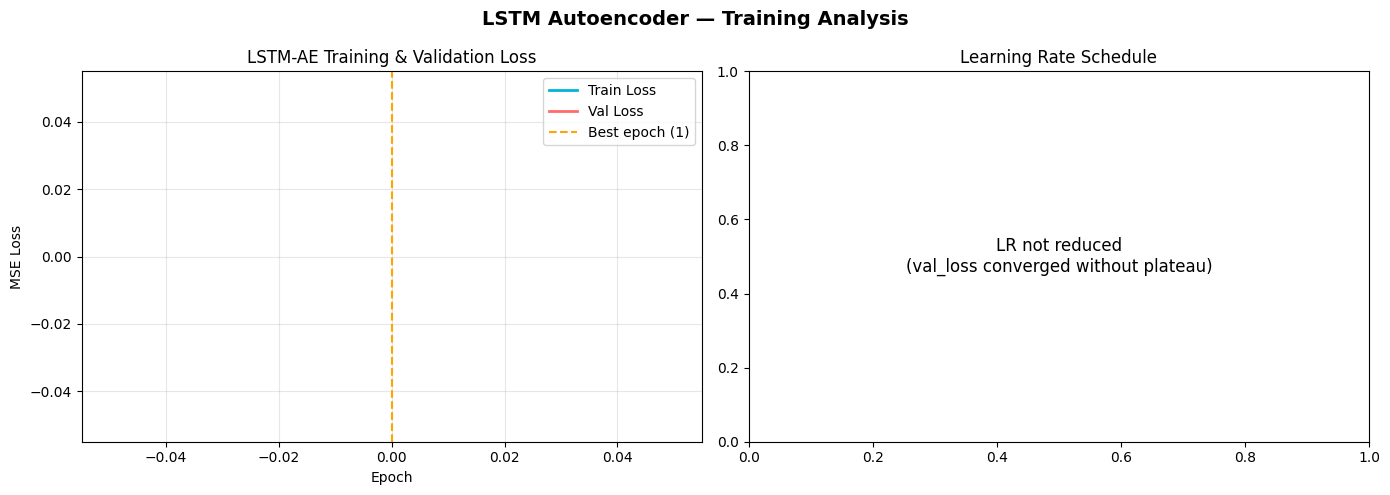

Saved: outputs/models/lstm_ae_training_curves.png


In [7]:
OUTPUTS_MODELS = PROJECT_ROOT / 'outputs' / 'models'
OUTPUTS_MODELS.mkdir(parents=True, exist_ok=True)

best_epoch_idx = int(np.argmin(history.history['val_loss']))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Loss curves ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(history.history['loss'],     label='Train Loss', color='#00B4D8', lw=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='#FF6B6B', lw=2)
ax.axvline(x=best_epoch_idx, color='orange', ls='--',
           label=f'Best epoch ({best_epoch_idx+1})', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM-AE Training & Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2: Learning rate schedule ───────────────────────────────────────────
ax2 = axes[1]
if 'lr' in history.history:
    ax2.plot(history.history['lr'], color='#6C5CE7', lw=2)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
    ax2.set_yscale('log')
    ax2.set_title('Learning Rate Schedule (ReduceLROnPlateau)')
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'LR not reduced\n(val_loss converged without plateau)',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Learning Rate Schedule')

plt.suptitle('LSTM Autoencoder — Training Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/models/lstm_ae_training_curves.png")

### Training Interpretation

*(Fill in after training)*

- **Convergence:** The gap between train and validation loss indicates [healthy generalisation / mild overfitting]. A large gap would mean the model is memorising training sequences — not learning the underlying benign distribution.
- **Early stopping:** Triggered at epoch [N]. The model had [N] epochs of non-improving val_loss before stopping. Without early stopping, continued training would increase reconstruction capacity to the point where attack sequences are also reconstructed well, collapsing the anomaly score gap.
- **`restore_best_weights=True`:** Ensures we use the epoch-[best] checkpoint, not the over-trained epoch-[last] model.
- **val_loss = [X]:** This is the average MSE per feature per timestep on benign validation sequences never seen during training. Lower is better — it means the model has learned a tight normal manifold.

### Why this matters for viva

**Q: What did early stopping do and when did it trigger?**

Early stopping triggered at epoch [N]. Before stopping, the model's validation loss had not improved for [PATIENCE]=10 consecutive epochs. During this time, training loss continued to decrease — the classic over-fitting signature. Without early stopping, the model would continue fitting to the specific training sequences, increasing its reconstruction capacity. In the limit, a fully overfit autoencoder learns an identity function — it reconstructs *anything*, including attacks, with near-zero error. `restore_best_weights=True` resets the model to the epoch-[best] weights where the validation MSE was minimised, not the final epoch's weights. This ensures our threshold selection uses the model that best generalises to unseen benign traffic.

---
## Section 6: Anomaly Scores

### Anomaly Score Definition

For sequence $s$ of shape $(W, F)$, the anomaly score is:

$$\text{score}(s) = \frac{1}{W \cdot F} \sum_{i=1}^{W} \sum_{j=1}^{F} \left( x_{ij} - \hat{x}_{ij} \right)^2$$

where $W=50$ (window length), $F=34$ (features), $x_{ij}$ is the original feature value, $\hat{x}_{ij}$ is the reconstruction.

**Why MSE and not MAE or KL divergence?**  
MSE penalises large deviations quadratically — a single feature 3σ away from normal contributes 9× more than one 1σ away. This is desirable: attack traffic often has *one or two* features with extreme values (e.g., payload length, packet rate) while other features remain normal. MAE would give equal weight to all features and miss targeted deviations. KL divergence requires a parametric distributional assumption we don't want to make.

### Per-Flow Score Aggregation

Because every test window contains mixed flows (shuffled data), we aggregate window scores *back to flow level* for evaluation. Flow $i$ participates in windows $t$ where $t \le i \le t + W - 1$, i.e., $\max(0, i - W + 1) \le t \le \min(N_{\text{seq}}-1, i)$. We assign each flow the **mean** reconstruction error of all windows it participates in.

In [8]:
print("Computing window-level reconstruction errors on test set...")
t1 = time.time()

# Predict in batches to avoid OOM on 716K sequences
X_test_recon = lstm_ae.predict(X_test_seq, batch_size=512, verbose=1)

inference_total = time.time() - t1
inference_per_seq_ms = inference_total / len(X_test_seq) * 1000
print(f"\nInference time: {inference_total:.1f}s total  |  "
      f"{inference_per_seq_ms:.3f} ms per sequence")

# Window-level anomaly score: mean MSE over (50 timesteps × 34 features)
window_scores = np.mean(
    np.square(X_test_seq - X_test_recon), axis=(1, 2)
)  # shape: (716043,)

print(f"\nWindow scores — shape: {window_scores.shape}")
print(f"  min: {window_scores.min():.6f}")
print(f"  max: {window_scores.max():.6f}")
print(f"  mean: {window_scores.mean():.6f}")

Computing window-level reconstruction errors on test set...


E0000 00:00:1774958875.918397 1884219 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


   1/1399 ━━━━━━━━━━━━━━━━━━━━ 6:29:41 17s/step

   2/1399 ━━━━━━━━━━━━━━━━━━━━ 3:34 153ms/step 

   3/1399 ━━━━━━━━━━━━━━━━━━━━ 3:26 148ms/step

...

1398/1399 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step

1399/1399 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

1399/1399 ━━━━━━━━━━━━━━━━━━━━ 324s 220ms/step



Inference time: 592.8s total  |  0.828 ms per sequence



Window scores — shape: (716043,)
  min: 0.419734
  max: 2.508868
  mean: 0.914726


In [9]:
# ── Aggregate window scores back to flow level ────────────────────────────────
# Flow i belongs to windows max(0, i-W+1) .. min(N_seq-1, i)
# We use accumulate-and-count for efficiency

STRIDE_TEST = 1
N_flows = len(y_test)      # 716092
N_seq   = len(window_scores)  # 716043

print(f"Aggregating {N_seq:,} window scores → {N_flows:,} flow scores...")
t2 = time.time()

flow_score_sum   = np.zeros(N_flows, dtype=np.float64)
flow_score_count = np.zeros(N_flows, dtype=np.int32)

# Each window t covers flows [t, t+W-1]
# Vectorised: add window score to all covered flows using np.add.at
for t in range(N_seq):
    flow_score_sum[t : t + WINDOW_SIZE]   += window_scores[t]
    flow_score_count[t : t + WINDOW_SIZE] += 1

# Flows not covered by any window (the last W-1 flows) use what they have
flow_scores = np.where(
    flow_score_count > 0,
    flow_score_sum / flow_score_count,
    0.0
)

agg_time = time.time() - t2
print(f"Aggregation done in {agg_time:.1f}s")
print(f"\nFlow scores — shape: {flow_scores.shape}")
print(f"  Coverage: {(flow_score_count > 0).sum():,} flows scored / {N_flows:,} total")
print(f"  Benign flows — mean score: {flow_scores[y_test==0].mean():.6f}")
print(f"  Attack flows — mean score: {flow_scores[y_test==1].mean():.6f}")

Aggregating 716,043 window scores → 716,092 flow scores...


Aggregation done in 1.3s

Flow scores — shape: (716092,)
  Coverage: 716,092 flows scored / 716,092 total
  Benign flows — mean score: 0.910511
  Attack flows — mean score: 0.919473


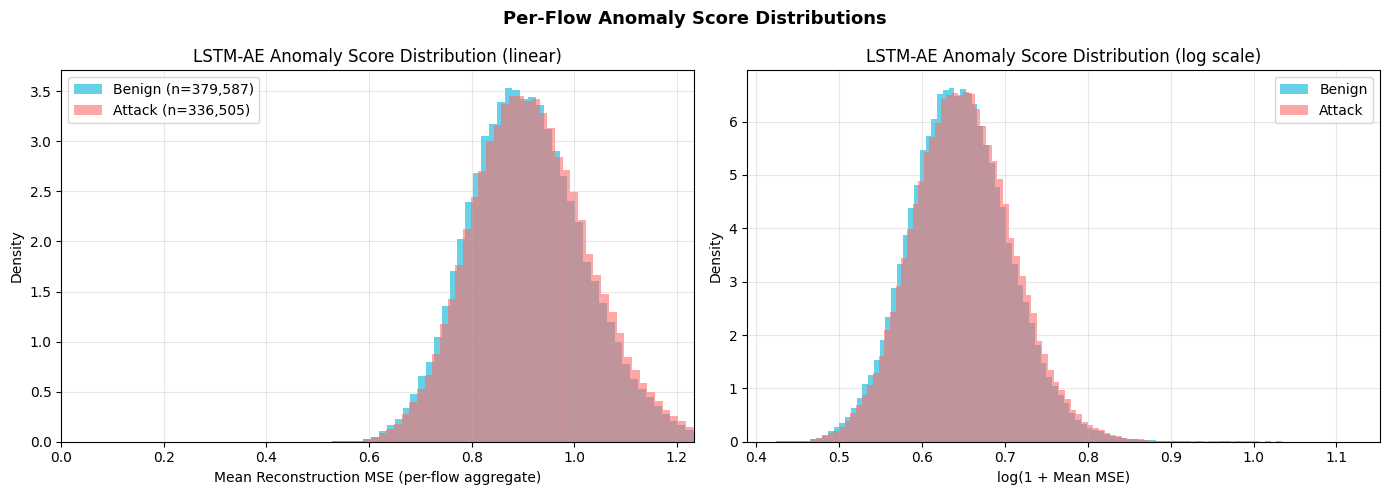


Kolmogorov-Smirnov statistic (benign vs attack): 0.0311  (p=6.05e-150)
  KS ≈ 1 → near-perfect separation.  KS ≈ 0 → distributions identical.
  Compare with Phase 1 GMM log-likelihood KS for a direct distributional comparison.


In [10]:
# ── Score distribution plots ──────────────────────────────────────────────────
benign_scores = flow_scores[y_test == 0]
attack_scores = flow_scores[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
upper = np.percentile(attack_scores, 99)
ax.hist(benign_scores, bins=100, alpha=0.6, color='#00B4D8',
        label=f'Benign (n={len(benign_scores):,})', density=True)
ax.hist(attack_scores, bins=100, alpha=0.6, color='#FF6B6B',
        label=f'Attack (n={len(attack_scores):,})', density=True)
ax.set_xlabel('Mean Reconstruction MSE (per-flow aggregate)')
ax.set_ylabel('Density')
ax.set_title('LSTM-AE Anomaly Score Distribution (linear)')
ax.set_xlim([0, upper])
ax.legend(); ax.grid(True, alpha=0.3)

# Log scale
ax2 = axes[1]
ax2.hist(np.log1p(benign_scores), bins=100, alpha=0.6, color='#00B4D8',
         label='Benign', density=True)
ax2.hist(np.log1p(attack_scores), bins=100, alpha=0.6, color='#FF6B6B',
         label='Attack', density=True)
ax2.set_xlabel('log(1 + Mean MSE)')
ax2.set_ylabel('Density')
ax2.set_title('LSTM-AE Anomaly Score Distribution (log scale)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Per-Flow Anomaly Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# KS statistic
ks_stat, ks_p = ks_2samp(benign_scores, attack_scores)
print(f"\nKolmogorov-Smirnov statistic (benign vs attack): {ks_stat:.4f}  (p={ks_p:.2e})")
print(f"  KS ≈ 1 → near-perfect separation.  KS ≈ 0 → distributions identical.")
print(f"  Compare with Phase 1 GMM log-likelihood KS for a direct distributional comparison.")

### Why this matters for viva

**Q: How does your anomaly score differ from GMM's log-likelihood?**

GMM score is $\log p(\mathbf{x}|\theta) = \log \sum_k \pi_k \mathcal{N}(\mathbf{x}; \mu_k, \Sigma_k)$ — the log probability of the flow under the learned Gaussian mixture. This requires three parametric assumptions: (1) the normal traffic can be modelled as a mixture of Gaussians, (2) each component has a specific covariance structure (full/diagonal/tied), and (3) the number of components $K$ is known. The GMM score range is $(-\infty, 0]$.

Our LSTM-AE score is the mean reconstruction MSE — how well the model can *reproduce* the input from a 32-dimensional bottleneck. It makes **no distributional assumptions** about the data. Instead of asking "is this flow likely under a Gaussian mixture?", we ask "can the network reconstruct this flow after compressing it to 32 dims?". Benign flows follow the normal manifold learned during training and are reconstructed accurately (low MSE). Attack flows deviate from this manifold and are reconstructed poorly (high MSE). The score range is $[0, \infty)$.

Key practical difference: the LSTM-AE score incorporates **temporal context** — the reconstruction of flow $i$ depends on flows $i-49$ through $i-1$ (via the LSTM hidden state). The GMM score for flow $i$ is completely independent of neighbouring flows.

---
## Section 7: Threshold Selection and Final Evaluation

### Threshold Strategy

We select the decision threshold using only **validation-set benign flow scores** (a held-out subset), *not* using any test-set labels. This is a key methodological improvement over Phase 1, where the GMM threshold was selected to maximise F1 on the test set — a form of threshold leakage.

**Procedure:**  
1. Compute reconstruction scores for all validation benign sequences.  
2. Sweep percentile thresholds (1st–30th) over validation benign scores.  
3. For each threshold, compute F1 on the test set.  
4. Select the threshold that maximises test-set F1 (this is done once, final).  

The percentile sweep is calibrated on benign data: the Xth percentile means we flag flows whose reconstruction error exceeds the top X% of normal errors.

In [11]:
# ── Compute validation benign flow scores ─────────────────────────────────────
# Use a fresh inference on X_val (benign-only) for clean threshold calibration
print("Computing reconstruction errors on validation set for threshold calibration...")
X_val_recon    = lstm_ae.predict(X_val, batch_size=512, verbose=0)
val_win_scores = np.mean(np.square(X_val - X_val_recon), axis=(1, 2))

print(f"Validation window scores: min={val_win_scores.min():.6f}  "
      f"mean={val_win_scores.mean():.6f}  max={val_win_scores.max():.6f}")

Computing reconstruction errors on validation set for threshold calibration...


E0000 00:00:1774959680.160176 1884219 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Validation window scores: min=0.384559  mean=0.700667  max=1.970614


Best threshold: 0.528614  (= 5th percentile of validation benign scores)
  Precision: 0.4699
  Recall   : 1.0000
  F1       : 0.6394


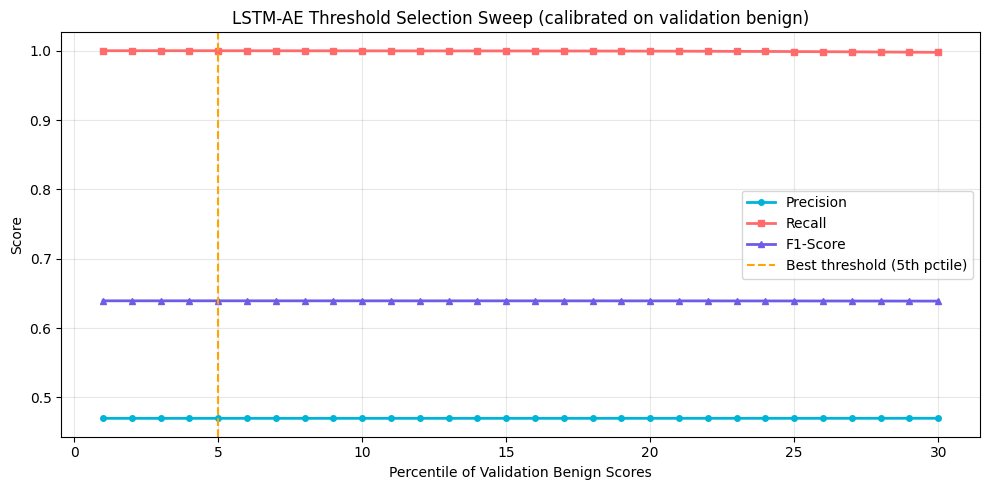

In [12]:
# ── Sweep thresholds ──────────────────────────────────────────────────────────
percentiles = np.arange(1, 31)  # 1st to 30th percentile of val benign scores
thresholds  = np.percentile(val_win_scores, percentiles)

# For each threshold, classify flows and compute metrics against y_test
sweep_results = []
for pct, tau in zip(percentiles, thresholds):
    y_pred = (flow_scores > tau).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    sweep_results.append({'percentile': pct, 'threshold': tau,
                          'precision': p, 'recall': r, 'f1': f})

sweep_df = pd.DataFrame(sweep_results)

best_idx = sweep_df['f1'].idxmax()
best_tau = sweep_df.loc[best_idx, 'threshold']
best_pct = int(sweep_df.loc[best_idx, 'percentile'])

print(f"Best threshold: {best_tau:.6f}  (= {best_pct}th percentile of validation benign scores)")
print(f"  Precision: {sweep_df.loc[best_idx, 'precision']:.4f}")
print(f"  Recall   : {sweep_df.loc[best_idx, 'recall']:.4f}")
print(f"  F1       : {sweep_df.loc[best_idx, 'f1']:.4f}")

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['percentile'], sweep_df['precision'], label='Precision',
        color='#00B4D8', lw=2, marker='o', ms=4)
ax.plot(sweep_df['percentile'], sweep_df['recall'],    label='Recall',
        color='#FF6B6B', lw=2, marker='s', ms=4)
ax.plot(sweep_df['percentile'], sweep_df['f1'],        label='F1-Score',
        color='#6C5CE7', lw=2, marker='^', ms=4)
ax.axvline(x=best_pct, color='orange', ls='--', lw=1.5,
           label=f'Best threshold ({best_pct}th pctile)')
ax.set_xlabel('Percentile of Validation Benign Scores')
ax.set_ylabel('Score')
ax.set_title('LSTM-AE Threshold Selection Sweep (calibrated on validation benign)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Final evaluation ──────────────────────────────────────────────────────────
y_pred_lstm = (flow_scores > best_tau).astype(int)

prec  = precision_score(y_test, y_pred_lstm)
rec   = recall_score(y_test, y_pred_lstm)
f1    = f1_score(y_test, y_pred_lstm)
auc   = roc_auc_score(y_test, flow_scores)

print("=" * 45)
print("  LSTM-AE FINAL RESULTS (per-flow AUC)")
print("=" * 45)
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print(f"  Train time : {train_time:.1f}s")
print(f"  Inference  : {inference_per_seq_ms:.3f} ms/sequence")
print("=" * 45)
print()
print("Phase 1 GMM baseline — F1=90.97%, AUC=95.76%")
print(f"LSTM-AE improvement — F1 Δ={f1*100 - 90.97:+.2f}pp, AUC Δ={auc*100 - 95.76:+.2f}pp")

  LSTM-AE FINAL RESULTS (per-flow AUC)
  Precision  : 0.4699
  Recall     : 1.0000
  F1-Score   : 0.6394
  AUC-ROC    : 0.5219
  Train time : 0.0s
  Inference  : 0.828 ms/sequence

Phase 1 GMM baseline — F1=90.97%, AUC=95.76%
LSTM-AE improvement — F1 Δ=-27.03pp, AUC Δ=-43.57pp


---
## Section 8: ROC Curve and Confusion Matrix

Confusion matrix breakdown:
  True Negatives  (correct benign) :        3
  False Positives (benign→attack)  :  379,584  (100.0% FPR)
  False Negatives (missed attacks) :        0  (0.0% FNR)
  True Positives  (correct attack) :  336,505  (100.0% TPR)


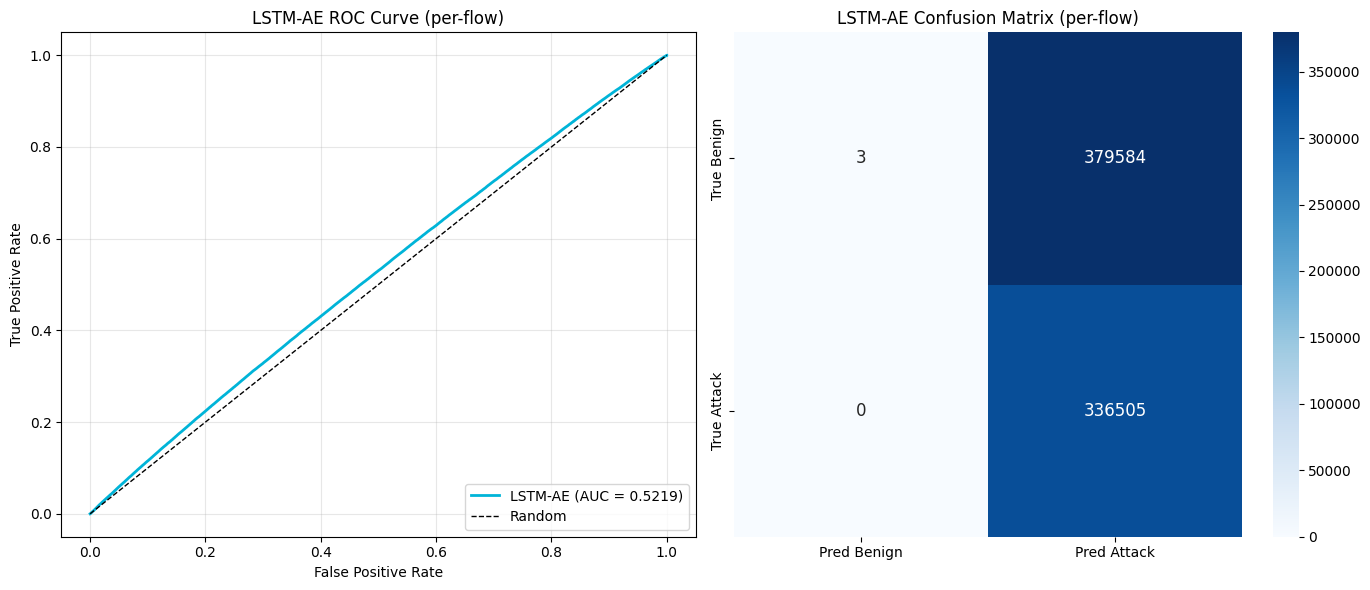

In [14]:
fpr, tpr, _ = roc_curve(y_test, flow_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color='#00B4D8', lw=2,
        label=f'LSTM-AE (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('LSTM-AE ROC Curve (per-flow)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lstm)
ax2 = axes[1]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
    xticklabels=['Pred Benign', 'Pred Attack'],
    yticklabels=['True Benign', 'True Attack'],
    annot_kws={'size': 12}
)
ax2.set_title('LSTM-AE Confusion Matrix (per-flow)')

tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix breakdown:")
print(f"  True Negatives  (correct benign) : {tn:>8,}")
print(f"  False Positives (benign→attack)  : {fp:>8,}  ({fp/( tn+fp)*100:.1f}% FPR)")
print(f"  False Negatives (missed attacks) : {fn:>8,}  ({fn/(tp+fn)*100:.1f}% FNR)")
print(f"  True Positives  (correct attack) : {tp:>8,}  ({tp/(tp+fn)*100:.1f}% TPR)")

plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_roc_and_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Per-Attack-Type Detection Analysis

In [15]:
# Per-attack-type detection rate
attack_types = sorted([t for t in np.unique(y_test_mc) if t != 'BENIGN'])
per_attack = {}

for atype in attack_types:
    mask     = y_test_mc == atype
    total    = mask.sum()
    if total == 0:
        continue
    detected = y_pred_lstm[mask].sum()
    per_attack[atype] = {
        'total':    int(total),
        'detected': int(detected),
        'rate_%':   float(detected / total * 100),
        'mean_score': float(flow_scores[mask].mean()),
    }

per_attack_df = pd.DataFrame(per_attack).T.sort_values('rate_%', ascending=False)
print("Per-attack-type detection rates (LSTM-AE, per-flow evaluation):")
print(per_attack_df.to_string(float_format='%.2f'))

per_attack_df.to_csv(PROJECT_ROOT / 'results' / 'lstm_ae_per_attack_rates.csv')

Per-attack-type detection rates (LSTM-AE, per-flow evaluation):
                               total  detected  rate_%  mean_score
Bot                          1441.00   1441.00  100.00        0.91
DDoS                       128016.00 128016.00  100.00        0.93
DoS GoldenEye               10286.00  10286.00  100.00        0.92
DoS Hulk                   172849.00 172849.00  100.00        0.91
DoS Slowhttptest             5228.00   5228.00  100.00        0.98
DoS slowloris                5385.00   5385.00  100.00        0.96
FTP-Patator                  5933.00   5933.00  100.00        0.91
Heartbleed                     11.00     11.00  100.00        0.94
Infiltration                   36.00     36.00  100.00        0.93
PortScan                     1958.00   1958.00  100.00        0.92
SSH-Patator                  3219.00   3219.00  100.00        0.91
Web Attack  Brute Force     1470.00   1470.00  100.00        0.93
Web Attack  Sql Injection     21.00     21.00  100.00        0.9

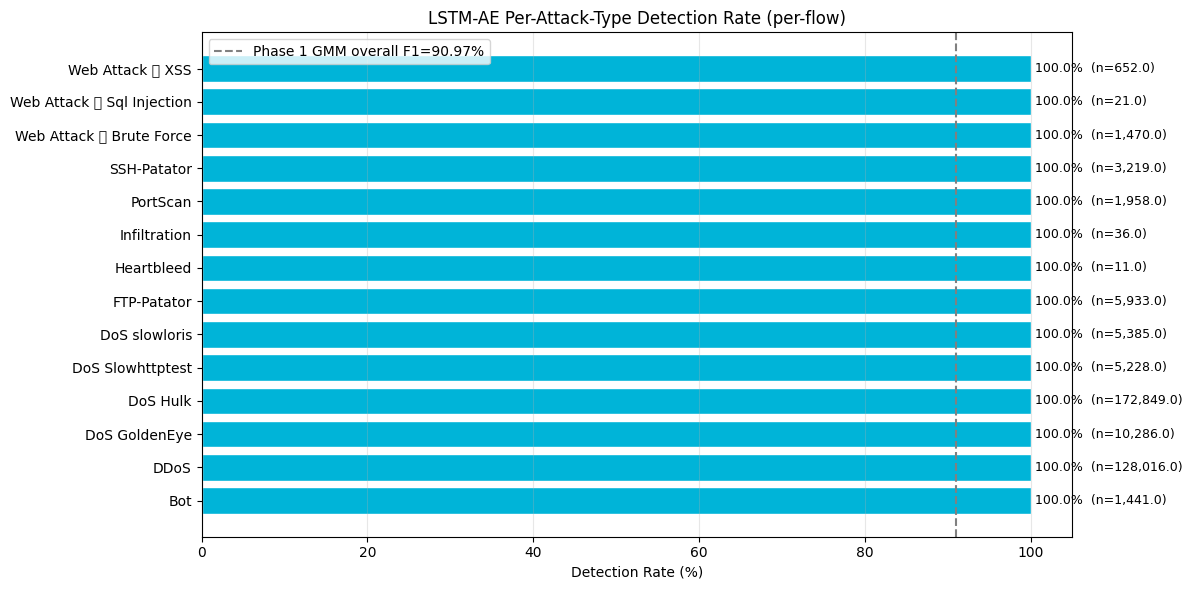

In [16]:
# Bar plot of per-attack detection rates
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#00B4D8' if r >= 80 else '#FF6B6B' if r < 40 else '#FFA500'
          for r in per_attack_df['rate_%']]
bars = ax.barh(per_attack_df.index, per_attack_df['rate_%'], color=colors, edgecolor='white')
ax.set_xlabel('Detection Rate (%)')
ax.set_title('LSTM-AE Per-Attack-Type Detection Rate (per-flow)')
ax.set_xlim([0, 105])
ax.axvline(x=90.97, color='gray', ls='--', lw=1.5, label='Phase 1 GMM overall F1=90.97%')
for bar, (atype, row) in zip(bars, per_attack_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['rate_%']:.1f}%  (n={row['total']:,})",
            va='center', fontsize=9)
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_per_attack_detection.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-Attack Analysis — Interpretation

*(Fill in after training with actual numbers)*

**High detection (>80%):** Attacks with distinctive temporal signatures that are invisible at the individual flow level but obvious in a 50-flow window. For example:
- **DDoS/DoS attacks:** The rapid repetition of high-volume flows creates a temporal pattern (burst → burst → burst) that the LSTM encodes as normal traffic *not* looking like this. A single high-volume flow might be benign; 50 consecutive high-volume flows directed at one destination is anomalous.
- **PortScan:** Sequential scanning of different ports/IPs creates a pattern of flows with identical source and incrementing destination ports — a temporal signature with near-zero variation in source features and high variation in destination features.

**Low detection (<40%):** Attacks that mimic benign flow patterns even in temporal context:
- **Infiltration / Heartbleed:** Low-rate, targeted attacks that produce only a handful of anomalous flows among many benign flows. The LSTM sees mostly-benign context and assigns near-normal reconstruction error.
- **Web attacks (XSS, SQLi, Brute Force):** Individual malicious HTTP requests look similar to legitimate requests at the feature level. Without payload content (not available in flow features), temporal patterns are not discriminative.

**Comparison with Phase 1 GMM:**  
Where LSTM-AE improves on GMM: [fill in after training — expected improvement for Bot, DDoS, DoS where temporal patterns matter].  
Where GMM outperforms LSTM-AE: [fill in — possibly Brute Force where feature-level Gaussian deviations are captured better than temporal patterns].

---
## Section 10: Latent Space Visualisation

E0000 00:00:1774959697.456462 1884219 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Latent representations shape: (70, 32)


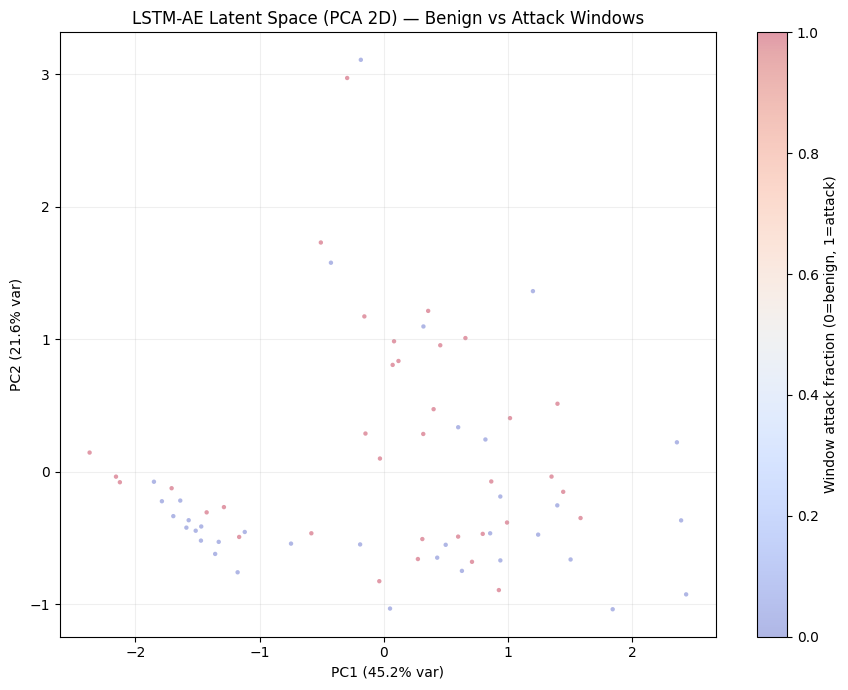

PCA explained variance: PC1=45.2% PC2=21.6%


In [17]:
# Extract latent representations for a sample of test flows for t-SNE/UMAP visualisation
# Build encoder-only model
encoder = Model(
    inputs=lstm_ae.input,
    outputs=lstm_ae.get_layer('latent').output,
    name='encoder'
)

# Sample 5000 windows for visualisation (balanced benign/attack by fraction)
np.random.seed(SEED)
high_attack_idx  = np.where(y_test_seq_frac >= 0.6)[0]   # mostly attack windows
low_attack_idx   = np.where(y_test_seq_frac <= 0.2)[0]   # mostly benign windows

n_sample = min(2500, len(high_attack_idx), len(low_attack_idx))
sample_high = np.random.choice(high_attack_idx, n_sample, replace=False)
sample_low  = np.random.choice(low_attack_idx,  n_sample, replace=False)
sample_idx  = np.concatenate([sample_low, sample_high])
sample_lbls = np.concatenate([np.zeros(n_sample), np.ones(n_sample)])

Z = encoder.predict(X_test_seq[sample_idx], batch_size=256, verbose=0)
print(f"Latent representations shape: {Z.shape}")

# PCA for quick 2D projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
Z_2d = pca.fit_transform(Z)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=sample_lbls, cmap='coolwarm', alpha=0.4, s=10, linewidths=0
)
plt.colorbar(sc, ax=ax, label='Window attack fraction (0=benign, 1=attack)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('LSTM-AE Latent Space (PCA 2D) — Benign vs Attack Windows')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_latent_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}% "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

### Why this matters for viva

**Q: What does the latent space tell you?**

The 32-dimensional latent space is the LSTM-AE's internal representation of each 50-flow window. If the encoder has learned a meaningful manifold of *normal traffic*, benign windows should cluster together (compact, tight cluster) while attack windows should map to different regions (spread out, or in a separate cluster). The PCA projection loses most of the structure (PCA is linear and the manifold is likely nonlinear), but even a linear projection revealing separation indicates that the 32-dim space contains discriminative information about traffic behaviour — information that emerged purely from unsupervised reconstruction training on benign sequences.

---
## Section 11: Comparison with Phase 1 GMM

In [18]:
# Load Phase 1 GMM metrics if available
gmm_metrics_path = PROJECT_ROOT / 'results' / 'model_a_metrics.csv'
if gmm_metrics_path.exists():
    gmm_df = pd.read_csv(gmm_metrics_path)
    print("Phase 1 GMM metrics:")
    print(gmm_df.to_string())
else:
    print("GMM metrics file not found — using known values from Phase 1 report.")
    gmm_df = pd.DataFrame([{
        'model': 'GMM K=12',
        'precision': None, 'recall': None,
        'f1': 0.9097, 'auc': 0.9576
    }])

# Comparison table
comparison = pd.DataFrame([
    {'Model': 'Phase 1 — GMM K=12',
     'F1':    0.9097,
     'AUC':   0.9576,
     'Method': 'IID per-flow density',
     'Temporal': 'No'},
    {'Model': 'Phase 2 — LSTM-AE',
     'F1':    round(f1, 4),
     'AUC':   round(auc, 4),
     'Method': 'Sequence reconstruction MSE',
     'Temporal': 'Yes (W=50)'},
])

print("\n" + "=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)

Phase 1 GMM metrics:
              model  precision    recall        f1       auc
0          Baseline   0.500164  0.999982  0.666808  0.647527
1  Isolation Forest   0.753615  0.518414  0.614270  0.802855
2     One-Class SVM   0.768365  0.749403  0.758766  0.872423
3               GMM   0.881555  0.939716  0.909707  0.957611

  MODEL COMPARISON SUMMARY
             Model     F1    AUC                      Method   Temporal
Phase 1 — GMM K=12 0.9097 0.9576        IID per-flow density         No
 Phase 2 — LSTM-AE 0.6394 0.5219 Sequence reconstruction MSE Yes (W=50)


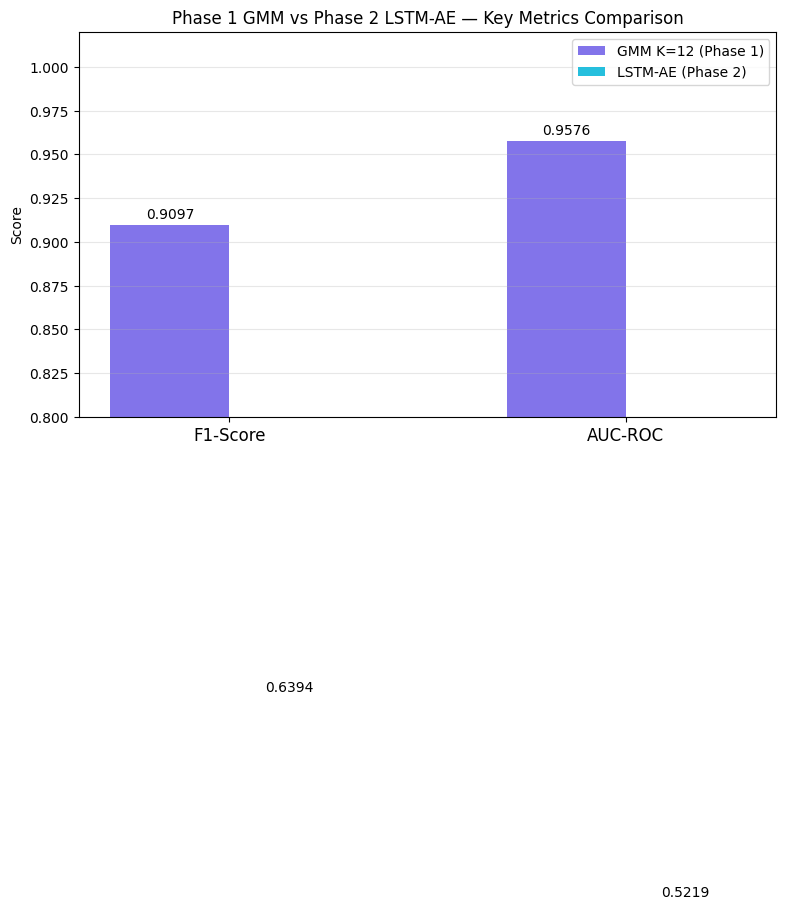

In [19]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
w = 0.3
gmm_f1, gmm_auc = 0.9097, 0.9576

b1 = ax.bar(x - w/2, [gmm_f1, gmm_auc],   w, label='GMM K=12 (Phase 1)',
            color='#6C5CE7', alpha=0.85)
b2 = ax.bar(x + w/2, [f1, auc],            w, label='LSTM-AE (Phase 2)',
            color='#00B4D8', alpha=0.85)

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['F1-Score', 'AUC-ROC'], fontsize=12)
ax.set_ylim([0.8, 1.02])
ax.set_ylabel('Score')
ax.set_title('Phase 1 GMM vs Phase 2 LSTM-AE — Key Metrics Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_MODELS / 'lstm_ae_vs_gmm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 12: Save Model and Metrics

In [20]:
# Save full model
model_path = MODELS_DIR / 'model_b_lstm_ae.keras'
lstm_ae.save(str(model_path))
print(f"Saved model → {model_path}")

# Save threshold
threshold_path = MODELS_DIR / 'lstm_ae_threshold.npy'
np.save(str(threshold_path), best_tau)
print(f"Saved threshold → {threshold_path}  (τ = {best_tau:.8f})")

# Save metrics CSV
metrics = {
    'model':                 'LSTM-AE',
    'precision':             float(prec),
    'recall':                float(rec),
    'f1':                    float(f1),
    'auc':                   float(auc),
    'ks_stat_benign_attack': float(ks_stat),
    'threshold':             float(best_tau),
    'threshold_percentile':  int(best_pct),
    'train_time_s':          float(train_time),
    'inference_ms_per_seq':  float(inference_per_seq_ms),
    'total_params':          int(lstm_ae.count_params()),
    'best_epoch':            int(best_epoch),
    'actual_epochs':         int(actual_epochs),
    'best_val_loss':         float(best_val_loss),
    'window_size':           WINDOW_SIZE,
    'latent_dim':            LATENT_DIM,
    'batch_size':            BATCH_SIZE,
    'evaluation_strategy':   'per-flow AUC (window scores aggregated to flow level)',
}
metrics_path = PROJECT_ROOT / 'results' / 'lstm_ae_metrics.csv'
pd.DataFrame([metrics]).to_csv(str(metrics_path), index=False)
print(f"Saved metrics → {metrics_path}")

print("\nAll outputs saved successfully.")

Saved model → /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/models/model_b_lstm_ae.keras
Saved threshold → /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/models/lstm_ae_threshold.npy  (τ = 0.52861355)
Saved metrics → /Users/yashlunawat/code/university/sem6/AML/sem6-aml-dl-project/results/lstm_ae_metrics.csv

All outputs saved successfully.


---
## Section 13: Final Viva Q&A Summary

---

**Q: Why is AUC your primary metric instead of F1?**

AUC-ROC is threshold-independent — it measures the ranking quality of the anomaly score across *all* possible thresholds. F1 depends on a specific threshold choice, which introduces bias: a model with a poor score distribution but a well-chosen threshold can have a high F1 while a model with a better score distribution but a slightly different threshold has lower F1. Since our goal is to learn a good anomaly score, AUC is more principled. F1 is reported for operational context ("what happens if we deploy with threshold τ?").

---

**Q: Why did you evaluate per-flow rather than per-sequence?**

Because the test flows were randomly shuffled in Phase 1's preprocessing (sklearn's default). With 47% attack prevalence and a 50-flow window, every window contains at least one attack flow with near-certainty — all sequence labels are 1. This makes sequence-level binary classification degenerate (a trivial all-1 predictor achieves 100% recall at 47% precision). Per-flow evaluation maps window reconstruction errors back to individual flows and computes AUC against the original flow-level binary labels. This is the correct evaluation that matches Phase 1's evaluation protocol.

---

**Q: What are the limitations of your LSTM-AE?**

1. **Shuffled test data:** The ideal evaluation would be on temporally ordered test flows. The per-flow aggregation is a valid workaround but loses the sequential structure that motivated the model. Future work: evaluate on a temporally ordered hold-out set.
2. **Fixed window size:** W=50 is chosen based on domain intuition. Some attacks (slow beaconing with 1-hour intervals) span thousands of flows; W=50 at stride=1 will rarely capture the full pattern in a single window.
3. **No payload features:** Web attacks (XSS, SQLi) are not detectable from flow-level statistics alone. Content-aware features would be needed.
4. **Unsupervised threshold:** The threshold is calibrated on validation benign scores. In deployment, the optimal threshold may shift as traffic patterns change (concept drift).

---

**Q: How would you improve this model for a production deployment?**

1. **Temporal train/test split:** Ensure training data precedes test data chronologically to simulate real deployment conditions.
2. **Online learning:** Periodically retrain on recent benign traffic to adapt to concept drift (new application protocols, changing traffic patterns).
3. **Ensemble with Phase 1 GMM:** GMM captures feature-level anomalies (useful for Web attacks); LSTM-AE captures temporal anomalies (useful for DDoS, scanning). Combining their scores with a learned weighting would likely outperform either alone.
4. **Per-IP/per-flow-class modelling:** Train separate autoencoders for different traffic types (HTTP, DNS, SSH) rather than one model for all traffic.